In [1]:
from __future__ import annotations

import json
import sqlite3
import sys
from dataclasses import asdict, dataclass
from itertools import product
from pathlib import Path
from typing import Any, Literal

sys.path.insert(0, str(Path().resolve().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scripts.main import ROOT

In [2]:
db_path = ROOT / "outputs" / "giant_experiment" / "runs.db"
conn = sqlite3.connect(db_path)
raw_df = pd.read_sql("SELECT run_id, data FROM results WHERE name = 'summary'", conn, index_col="run_id")
conn.close()

raw_df.head()

,data
run_id,
ti_iid-block_iid_noise-1-10,"{""scalars"": {""ln_evidence"": 27295.440805977694..."
ti_iid-block_iid_noise-1-1,"{""scalars"": {""ln_evidence"": 25479.247753247328..."
ti_iid-block_iid_noise-1-50,"{""scalars"": {""ln_evidence"": 28340.1313687754},..."
ti_iid-block_iid_noise-1-40,"{""scalars"": {""ln_evidence"": 27902.622714922963..."
ti_iid-block_iid_noise-2-20,"{""scalars"": {""ln_evidence"": 28055.926076154446..."


In [4]:
@dataclass(frozen=True)
class RunConfig:
    forward: Literal["CA", "RTI", "I"]
    noise: Literal["block_iid", "block_iid+correlated"]
    prior: Literal["iid", "correlated"]
    ssi_ak_bias: bool
    rad_res: int
    lat_res: int


@dataclass(frozen=True)
class _RawResult:
    ln_evidence: str | None
    mahalanobis_total: str | None
    mahalanobis_ssi_ak: str | None
    mahalanobis_ssi_ak_comp: str | None


@dataclass(frozen=True)
class RunResult:
    ln_evidence: float
    mahalanobis_total: float | None = None
    mahalanobis_ssi_ak: float | None = None
    mahalanobis_ssi_ak_comp: float | None = None

    @classmethod
    def from_raw(cls, raw: _RawResult) -> RunResult:
        if raw.ln_evidence is None:
            raise ValueError("Missing log evidence")
        else:
            ln_Z = float(raw.ln_evidence)

        def _none_or_float(v: str | None) -> float | None:
            return v if v is None else float(v)

        return cls(
            ln_Z,
            _none_or_float(raw.mahalanobis_total),
            _none_or_float(raw.mahalanobis_ssi_ak),
            _none_or_float(raw.mahalanobis_ssi_ak_comp),
        )

    @classmethod
    def from_raw_dict(cls, d: dict[str, str]) -> RunResult:
        raw = _RawResult(
            d.get("ln_evidence"),
            d.get("mahalanobis_total"),
            d.get("mahalanobis_ssi_ak"),
            d.get("mahalanobis_ssi_ak_comp")
        )
        return cls.from_raw(raw)


def parse_run_id(run_id: str) -> RunConfig:
    bits = run_id.split("-")
    if len(bits) < 4:
        raise ValueError(f"Unexpected run_id: {run_id}")
    lat_res = bits.pop(-1)
    rad_res = bits.pop(-1)

    fwd_prior = bits.pop(0)
    fwd, prior = fwd_prior.split("_")
    fwd_map = {"ti": "CA", "rti": "RTI", "iso": "I"}
    prior_map = {"iid": "iid", "corr": "correlated"}

    ssi_ak_bias = "ssi_ak_bias" in bits
    if ssi_ak_bias:
        bits.remove("ssi_ak_bias")

    if len(bits) == 1:
        noise = "block_iid"
    elif len(bits) == 2:
        noise = "block_iid+correlated"
    else:
        raise ValueError("Unexpected length of run_id")

    return RunConfig(
        fwd_map[fwd],
        noise,
        prior_map[prior],
        ssi_ak_bias,
        int(rad_res),
        int(lat_res),
    )


def parse_results_dict(d: dict[str, dict[str, Any]]) -> RunResult:
    scalars = d["scalars"]
    return RunResult.from_raw_dict(scalars)


def parse_row(r: pd.Series) -> dict[str, Any]:
    run_id = r.name
    raw = r.get("data", None)

    cfg = parse_run_id(run_id)
    res = parse_results_dict(json.loads(raw))
    return asdict(cfg) | asdict(res)


df = pd.DataFrame(raw_df.apply(parse_row, axis=1).values.tolist())

df.head()


,forward,noise,prior,ssi_ak_bias,rad_res,lat_res,ln_evidence,mahalanobis_total,mahalanobis_ssi_ak,mahalanobis_ssi_ak_comp
0,CA,block_iid,iid,False,1,10,27295.440806,None,None,None
1,CA,block_iid,iid,False,1,1,25479.247753,None,None,None
2,CA,block_iid,iid,False,1,50,28340.131369,None,None,None
3,CA,block_iid,iid,False,1,40,27902.622715,None,None,None
4,CA,block_iid,iid,False,2,20,28055.926076,None,None,None


In [5]:
cfg_options = {
    k: df[k].unique().tolist() for k in ["forward", "noise", "prior", "ssi_ak_bias"]
}
cfg_options

{'forward': ['CA', 'RTI', 'I'],
 'noise': ['block_iid', 'block_iid+correlated'],
 'prior': ['iid', 'correlated'],
 'ssi_ak_bias': [False, True]}

In [6]:
lat_res_index_map = {lr: i for i, lr in enumerate(np.sort(df["lat_res"].unique()))}
rad_res_index_map = {lr: i for i, lr in enumerate(np.sort(df["rad_res"].unique()))}
grids: dict[str, np.ndarray] = {}
for cfg in product(*cfg_options.values()):
    cfg_str = "-".join(str(c) for c in cfg)
    filter = (df["forward"] == cfg[0]) & (df["noise"] == cfg[1]) & (df["prior"] == cfg[2]) & (df["ssi_ak_bias"] == cfg[3])
    sub = df[filter]
    grid = np.nan * np.ones((len(rad_res_index_map), len(lat_res_index_map)), dtype=float)
    for (_, row) in sub.iterrows():
        rr = row["rad_res"]
        lr = row["lat_res"]
        ln_Z = row["ln_evidence"]
        lr_idx = lat_res_index_map[lr]
        rr_idx = rad_res_index_map[rr]
        grid[rr_idx, lr_idx] = ln_Z
    grids[cfg_str] = grid

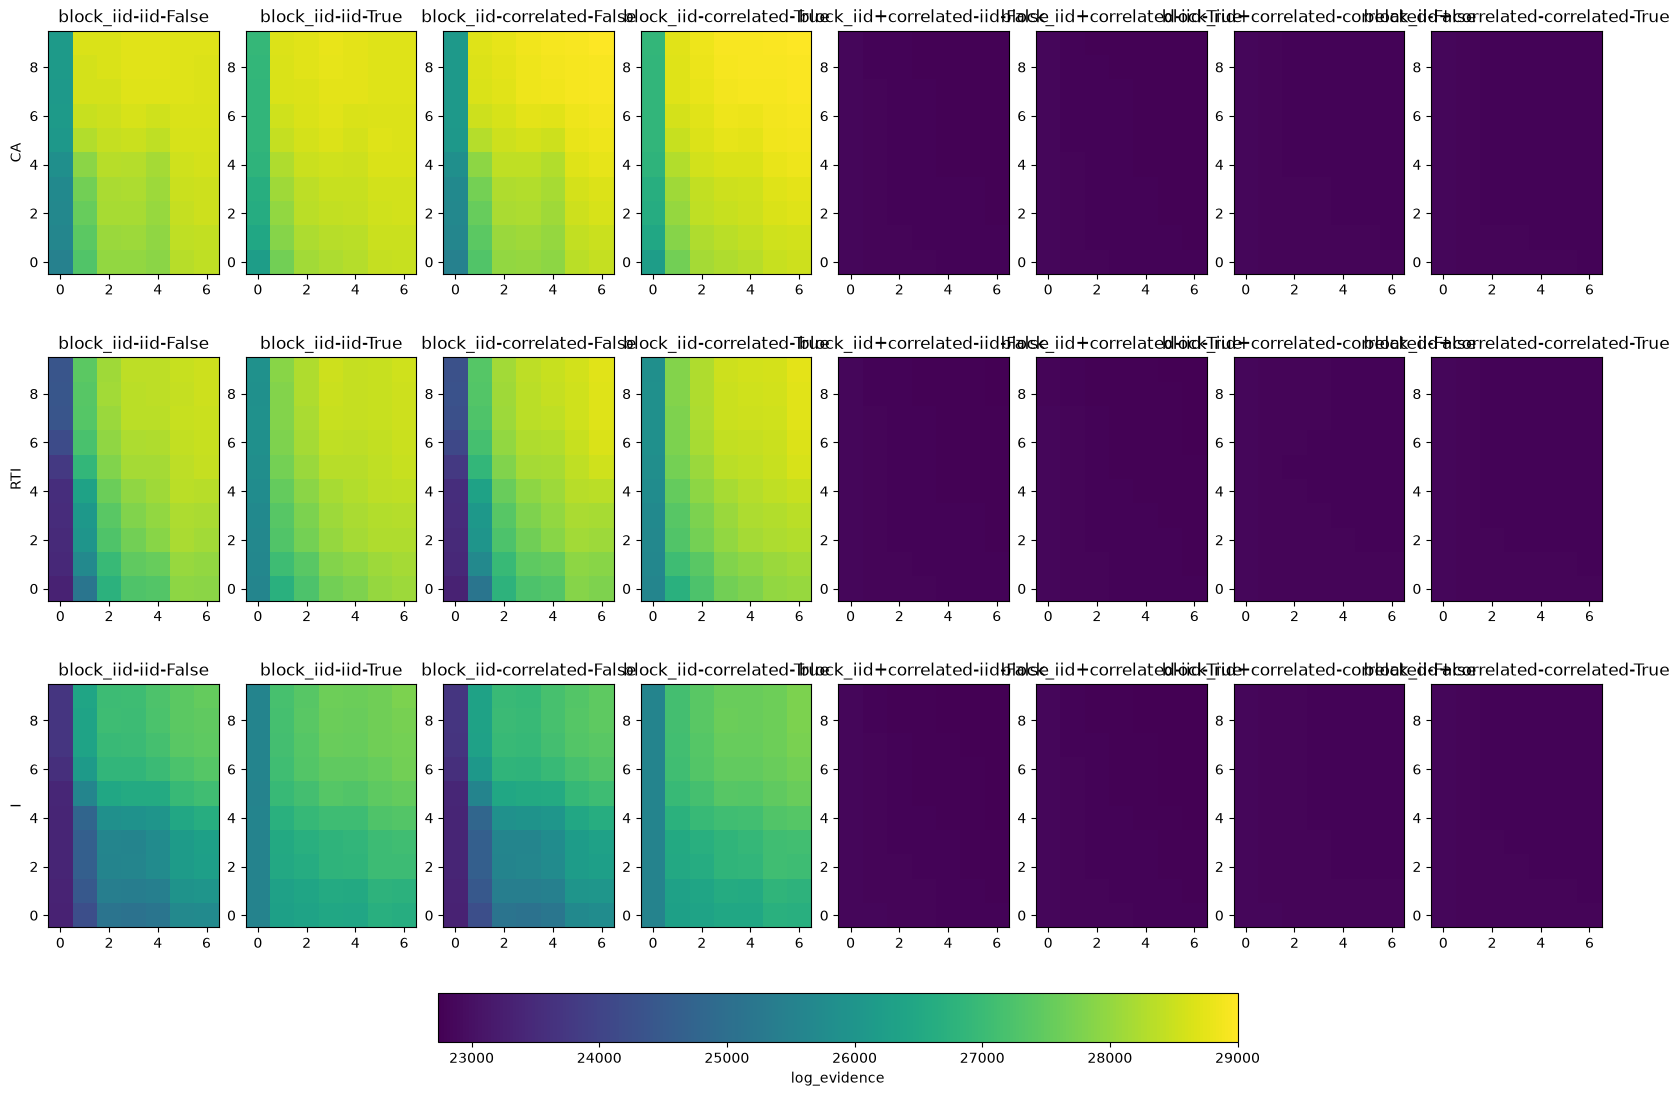

In [7]:
def grid_figsize(nrows, ncols):
    width_per_col = 2.0
    height_per_row = 3.0
    top_bottom_margin = 0.8

    width = ncols * width_per_col
    height = nrows * height_per_row + top_bottom_margin
    return (width, height)


nrows = len(cfg_options["forward"])
ncols = (
    len(cfg_options["noise"])
    * len(cfg_options["prior"])
    * len(cfg_options["ssi_ak_bias"])
)
fig, axs = plt.subplots(
    nrows, ncols, figsize=grid_figsize(nrows, ncols), layout="constrained"
)
norm = plt.Normalize(
    min(np.min(g) for g in grids.values()), max(np.max(g) for g in grids.values())
)
for r, forward in enumerate(cfg_options["forward"]):
    c = 0
    for cfg in product(*cfg_options.values()):
        if cfg[0] != forward:
            continue
        cfg_str = "-".join(str(c) for c in cfg)
        ax = axs[r, c]
        ax.imshow(grids[cfg_str], origin="lower", norm=norm)
        ax.set_title("-".join(str(c) for c in cfg[1:]))

        c += 1
for ax, fwd in zip(axs[:, 0], cfg_options["forward"]):
    ax.set_ylabel(fwd)

cbar_ax = fig.add_axes((0.27, -0.075, 0.5, 0.05))
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm, "viridis"),
    cax=cbar_ax,
    orientation="horizontal",
    label="log_evidence",
)


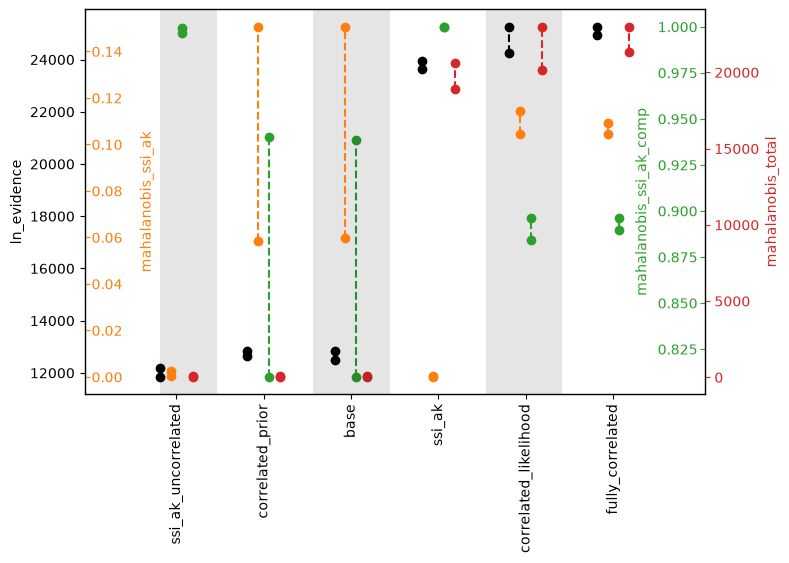

In [ ]:
maxmins: dict[str, dict[str, tuple[float, float]]] = {}
for exp, d in grids.items():
    exp_d: dict[str, tuple[float, float]] = {}
    for name, grid in d.items():
        exp_d[name] = (float(np.nanmin(grid))), float(np.nanmax(grid))
    maxmins[exp] = {k: exp_d[k] for k in sorted(exp_d)}
# sort experiments by maximum evidence
maxmins = {k: maxmins[k] for k in sorted(maxmins, key=lambda x: maxmins[x]["ln_evidence"][1])}

exp_x = np.linspace(0, 1, len(grids))

exp_x_spacings = (exp_x[1:] - exp_x[:-1])[0]
metric_x_spacings = (exp_x_spacings / 2) / len(grid_names)
metric_x_relative = (
    metric_x_spacings * np.arange(len(grid_names))
    - (metric_x_spacings * np.arange(len(grid_names))).max() / 2
)
metric_x = exp_x[:, None] + metric_x_relative
fig, left1 = plt.subplots(figsize=(8, 5))

right1 = left1.twinx()
right2 = left1.twinx()
left2 = left1.twinx()

axs = [left1, left2, right1, right2]
colours = ["k", "C1", "C2", "C3"]

for d, x_pos in zip(maxmins.values(), metric_x):
    for ax, x, (name, maxmin), c in zip(axs, x_pos, d.items(), colours):
        ax.plot([x, x], maxmin, f"o--{c}")
        ax.set_ylabel(name, labelpad=-50 if ax in [left2, right1] else None)

xline = np.linspace(metric_x.min(), metric_x.max())
for ax, x in zip(axs, exp_x[::2]):
    ax.fill_between(
        xline,
        0,
        1,
        where=(xline >= x - exp_x_spacings / 2) & (xline <= x + exp_x_spacings / 2),
        color="k",
        linewidth=0,
        alpha=0.1,
        transform=ax.get_xaxis_transform(),
    )

left2.yaxis.set_label_position("left")
left2.yaxis.set_ticks_position("left")

left2.tick_params("y", direction="in", pad=-5)
for ticklabel in left2.get_yticklabels():
    ticklabel.set_horizontalalignment("left")
right1.tick_params("y", direction="in", pad=-5)
for ticklabel in right1.get_yticklabels():
    ticklabel.set_horizontalalignment("right")

for ax, colour in zip(axs, colours):
    ax.tick_params("y", color=colour)
    for ticklabel in ax.get_yticklabels():
        ticklabel.set_color(colour)
    ax.set_ylabel(ax.get_ylabel(), color=colour)

xlim = left1.get_xlim()
buff = (xlim[1] - xlim[0]) * 0.1
left1.set_xlim(xlim[0] - buff, xlim[1] + buff)

left1.set_xticks(exp_x, maxmins.keys(), rotation=90, rotation_mode="xtick")
